In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
sns.set_style("whitegrid")

In [24]:
df = pd.read_csv("data.csv")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicate Rows: {df.duplicated().sum()}")
print(f"Data Shape: {df.shape}")
df.head()

Missing values: 954922
Duplicate Rows: 0
Data Shape: (282451, 16)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,Meta1,Meta2,Meta3,Meta4,Meta5,CPI,Unemployment,Type,Size
0,26,92,2011-08-26,87235.57,False,61.10,3.796,NaN,NaN,NaN,NaN,NaN,136.213613,7.767,A,152513
1,34,22,2011-03-25,5945.97,False,53.11,3.480,NaN,NaN,NaN,NaN,NaN,128.616064,10.398,A,158114
2,21,28,2010-12-03,1219.89,False,50.43,2.708,NaN,NaN,NaN,NaN,NaN,211.265543,8.163,B,140167
3,8,9,2010-09-17,11972.71,False,75.32,2.582,NaN,NaN,NaN,NaN,NaN,214.878556,6.315,A,155078
4,19,55,2012-05-18,8271.82,False,58.81,4.029,12613.98,NaN,11.5,1705.28,3600.79,138.106581,8.150,A,203819


In [25]:
df.info()
print("\nDescriptive stats:")
df.describe().round(3)

<class 'pandas.DataFrame'>
RangeIndex: 282451 entries, 0 to 282450
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         282451 non-null  int64  
 1   Dept          282451 non-null  int64  
 2   Date          282451 non-null  str    
 3   Weekly_Sales  282451 non-null  float64
 4   IsHoliday     282451 non-null  bool   
 5   Temperature   282451 non-null  float64
 6   Fuel_Price    282451 non-null  float64
 7   Meta1         100520 non-null  float64
 8   Meta2         74232 non-null   float64
 9   Meta3         91521 non-null   float64
 10  Meta4         90031 non-null   float64
 11  Meta5         101029 non-null  float64
 12  CPI           282451 non-null  float64
 13  Unemployment  282451 non-null  float64
 14  Type          282451 non-null  str    
 15  Size          282451 non-null  int64  
dtypes: bool(1), float64(10), int64(3), str(2)
memory usage: 32.6 MB

Descriptive stats:


,Store,Dept,Weekly_Sales,Temperature,Fuel_Price,Meta1,Meta2,Meta3,Meta4,Meta5,CPI,Unemployment,Size
count,282451.000,282451.000,282451.000,282451.000,282451.000,100520.000,74232.000,91521.000,90031.000,101029.000,282451.000,282451.000,282451.000
mean,22.193,44.286,15983.430,60.114,3.360,7246.078,3318.408,1417.398,3379.592,4639.476,171.208,7.968,136730.073
std,12.782,30.504,22661.092,18.446,0.459,8254.606,9485.576,9547.859,6269.428,6060.460,39.161,1.868,61002.319
min,1.000,1.000,-4988.940,-2.060,2.472,0.270,-265.760,-29.100,0.220,135.160,126.064,3.879,34875.000
25%,11.000,18.000,2079.330,46.780,2.932,2241.190,40.960,5.060,508.100,1877.810,132.023,6.891,93638.000
50%,22.000,38.000,7616.550,62.150,3.452,5363.520,191.820,24.340,1482.030,3364.410,182.351,7.866,140167.000
75%,33.000,74.000,20245.745,74.290,3.737,9235.590,1919.790,103.130,3607.570,5563.800,212.465,8.572,202505.000
max,45.000,99.000,693099.360,100.140,4.468,88646.760,104519.540,141630.610,67474.850,108519.280,227.233,14.313,219622.000


In [26]:
meta_cols = ["Meta1", "Meta2", "Meta3", "Meta4", "Meta5"]
print("Missing before:")
print(df[meta_cols].isnull().sum())

df[meta_cols] = df[meta_cols].fillna(df[meta_cols].mean())

print("\nMissing after:")
print(df[meta_cols].isnull().sum())
df[meta_cols].head()

Missing before:
Meta1    181931
Meta2    208219
Meta3    190930
Meta4    192420
Meta5    181422
dtype: int64

Missing after:
Meta1    0
Meta2    0
Meta3    0
Meta4    0
Meta5    0
dtype: int64


,Meta1,Meta2,Meta3,Meta4,Meta5
0,7246.077559,3318.408122,1417.397841,3379.591745,4639.476021
1,7246.077559,3318.408122,1417.397841,3379.591745,4639.476021
2,7246.077559,3318.408122,1417.397841,3379.591745,4639.476021
3,7246.077559,3318.408122,1417.397841,3379.591745,4639.476021
4,12613.980000,3318.408122,11.500000,1705.280000,3600.790000


In [27]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Store", "Date"]).reset_index(drop=True)

print(f"Data period: {df['Date'].min()} to {df['Date'].max()}")
print(f"Number of stores: {df['Store'].nunique()}")

Data period: 2010-02-05 00:00:00 to 2012-10-26 00:00:00
Number of stores: 45


In [28]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,Meta1,Meta2,Meta3,Meta4,Meta5,CPI,Unemployment,Type,Size
0,1,5,2010-02-05,32229.38,False,42.31,2.572,7246.077559,3318.408122,1417.397841,3379.591745,4639.476021,211.096358,8.106,A,151315
1,1,8,2010-02-05,40129.01,False,42.31,2.572,7246.077559,3318.408122,1417.397841,3379.591745,4639.476021,211.096358,8.106,A,151315
2,1,24,2010-02-05,8272.90,False,42.31,2.572,7246.077559,3318.408122,1417.397841,3379.591745,4639.476021,211.096358,8.106,A,151315
3,1,85,2010-02-05,3825.78,False,42.31,2.572,7246.077559,3318.408122,1417.397841,3379.591745,4639.476021,211.096358,8.106,A,151315
4,1,44,2010-02-05,4674.75,False,42.31,2.572,7246.077559,3318.408122,1417.397841,3379.591745,4639.476021,211.096358,8.106,A,151315


In [29]:
store_week = (
    df.groupby(["Store", "Date"], as_index=False)
      .agg(
          Weekly_Sales=("Weekly_Sales", "sum"),
          IsHoliday=("IsHoliday", "max"),
          Temperature=("Temperature", "mean"),
          Fuel_Price=("Fuel_Price", "mean"),
          CPI=("CPI", "mean"),
          Unemployment=("Unemployment", "mean"),
          Type=("Type", "first"),
          Size=("Size", "first"),
          Meta1=("Meta1", "mean"),
          Meta2=("Meta2", "mean"),
          Meta3=("Meta3", "mean"),
          Meta4=("Meta4", "mean"),
          Meta5=("Meta5", "mean"),
      )
      .sort_values(["Store", "Date"])
      .reset_index(drop=True)
)

print(f"Store-week shape: {store_week.shape}")
store_week.head()

Store-week shape: (6435, 15)


,Store,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,CPI,Unemployment,Type,Size,Meta1,Meta2,Meta3,Meta4,Meta5
0,1,2010-02-05,1112466.82,False,42.31,2.572,211.096358,8.106,A,151315,7246.077559,3318.408122,1417.397841,3379.591745,4639.476021
1,1,2010-02-12,792483.02,True,38.51,2.548,211.242170,8.106,A,151315,7246.077559,3318.408122,1417.397841,3379.591745,4639.476021
2,1,2010-02-19,799708.54,False,39.93,2.514,211.289143,8.106,A,151315,7246.077559,3318.408122,1417.397841,3379.591745,4639.476021
3,1,2010-02-26,968441.71,False,46.63,2.561,211.319643,8.106,A,151315,7246.077559,3318.408122,1417.397841,3379.591745,4639.476021
4,1,2010-03-05,1021063.19,False,46.50,2.625,211.350143,8.106,A,151315,7246.077559,3318.408122,1417.397841,3379.591745,4639.476021


In [ ]:
#ADDON remove column size and type for tong cong y
# store_week = (
#     df.groupby(["Date"], as_index=False)
#       .agg(
#           Weekly_Sales=("Weekly_Sales", "sum"),
#           IsHoliday=("IsHoliday", "max"),
#           Temperature=("Temperature", "mean"),
#           Fuel_Price=("Fuel_Price", "mean"),
#           CPI=("CPI", "mean"),
#           Unemployment=("Unemployment", "mean"),
#           Meta1=("Meta1", "mean"),
#           Meta2=("Meta2", "mean"),
#           Meta3=("Meta3", "mean"),
#           Meta4=("Meta4", "mean"),
#           Meta5=("Meta5", "mean"),
#       )
#       .sort_values(["Date"])
#       .reset_index(drop=True)
# )

# print(f"Store-week shape: {store_week.shape}")
# store_week.head()

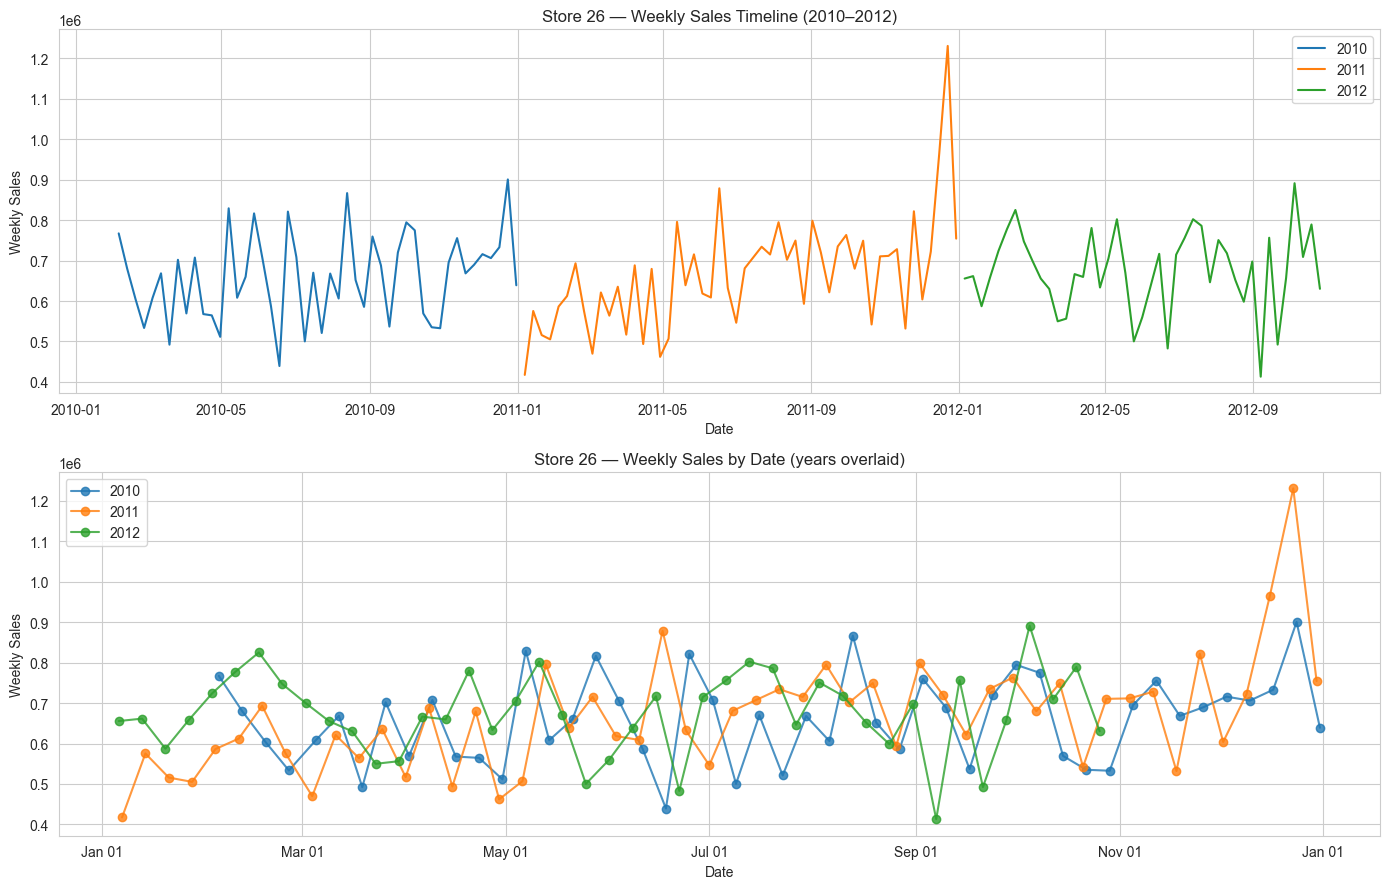

In [30]:
from matplotlib.dates import DateFormatter

store_id = 26
s26 = store_week[store_week["Store"] == store_id].copy()
s26["Year"] = s26["Date"].dt.year
s26["MonthDay"] = s26["Date"].apply(lambda d: d.replace(year=2000))

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

for year in [2010, 2011, 2012]:
    sub = s26[s26["Year"] == year]
    axes[0].plot(sub["Date"], sub["Weekly_Sales"], label=str(year))
    axes[1].plot(sub["MonthDay"], sub["Weekly_Sales"], marker="o", label=str(year), alpha=0.8)

axes[0].set(title=f"Store {store_id} — Weekly Sales Timeline (2010–2012)", xlabel="Date", ylabel="Weekly Sales")
axes[1].set(title=f"Store {store_id} — Weekly Sales by Date (years overlaid)", xlabel="Date", ylabel="Weekly Sales")
axes[1].xaxis.set_major_formatter(DateFormatter("%b %d"))
axes[0].legend(); axes[1].legend()

plt.tight_layout()
plt.show()

In [31]:
# Feature Engineering
data = store_week.copy()
data["Year"] = data["Date"].dt.year
data["Month"] = data["Date"].dt.month
data["Week"] = data["Date"].dt.isocalendar().week.astype(int)
data["DayOfYear"] = data["Date"].dt.dayofyear
data["IsHoliday"] = data["IsHoliday"].astype(int)
data["Type"] = data["Type"].astype("category").cat.codes

for lag in [1, 2, 4, 52]:
    data[f"Sales_Lag_{lag}"] = data.groupby("Store")["Weekly_Sales"].shift(lag)

data["Sales_Roll4_Mean"] = (
    data.groupby("Store")["Weekly_Sales"].shift(1).rolling(4).mean().reset_index(0, drop=True)
)

data = data.dropna().reset_index(drop=True)
print(f"Modeling shape: {data.shape}")
data.head()

Modeling shape: (4095, 24)


,Store,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,CPI,Unemployment,Type,Size,Meta1,Meta2,Meta3,Meta4,Meta5,Year,Month,Week,DayOfYear,Sales_Lag_1,Sales_Lag_2,Sales_Lag_4,Sales_Lag_52,Sales_Roll4_Mean
0,1,2011-02-04,1068034.66,0,42.27,2.989,212.566881,7.742,0,151315,7246.077559,3318.408122,1417.397841,3379.591745,4639.476021,2011,2,5,35,899004.45,918366.32,1015595.03,1112466.82,9.381366e+05
1,1,2011-02-11,899464.96,1,36.39,3.022,212.936705,7.742,0,151315,7246.077559,3318.408122,1417.397841,3379.591745,4639.476021,2011,2,6,42,1068034.66,899004.45,919580.78,792483.02,9.512466e+05
2,1,2011-02-18,1133131.80,0,57.36,3.045,213.247885,7.742,0,151315,7246.077559,3318.408122,1417.397841,3379.591745,4639.476021,2011,2,7,49,899464.96,1068034.66,918366.32,799708.54,9.462176e+05
3,1,2011-02-25,1027711.67,0,62.90,3.065,213.535609,7.742,0,151315,7246.077559,3318.408122,1417.397841,3379.591745,4639.476021,2011,2,8,56,1133131.80,899464.96,899004.45,968441.71,9.999090e+05
4,1,2011-03-04,1011590.25,0,59.58,3.288,213.823333,7.742,0,151315,7246.077559,3318.408122,1417.397841,3379.591745,4639.476021,2011,3,9,63,1027711.67,1133131.80,1068034.66,1021063.19,1.032086e+06


In [32]:
feature_cols = [
    "Store", "IsHoliday", "Temperature", "Fuel_Price", "CPI", "Unemployment",
    "Type", "Size", "Year", "Month", "Week", "DayOfYear",
    "Sales_Lag_1", "Sales_Lag_2", "Sales_Lag_4", "Sales_Lag_52", "Sales_Roll4_Mean",
] + meta_cols

target_col = "Weekly_Sales"

# Test Correlation
selected = feature_cols
corr = data[feature_cols + [target_col]].corr()
# Categorical, encode from categorical to numeric for correlation calculation
# A -> 1, B -> 2, C -> 3 for "Type" column
# Grade B, C, A-, A+ ---> 1, 2, 3, 4 for "Type" column
target_corr = corr[target_col].drop(target_col).sort_values(key=abs, ascending=False)
print(target_corr.round(3).to_string())

Sales_Roll4_Mean    0.923
Sales_Lag_52        0.911
Sales_Lag_1         0.891
Sales_Lag_2         0.886
Sales_Lag_4         0.880
Size                0.792
Type               -0.588
Store              -0.325
Meta1               0.244
Meta5               0.230
Meta3               0.122
Unemployment       -0.111
Meta4               0.106
CPI                -0.072
Month               0.059
DayOfYear           0.057
Week                0.057
Temperature        -0.055
Meta2               0.055
IsHoliday           0.037
Year               -0.021
Fuel_Price          0.008


In [33]:
split_date = data["Date"].quantile(0.8)
train = data[data["Date"] <= split_date]
test = data[data["Date"] > split_date]

X_train, y_train = train[selected], train[target_col]
X_test, y_test = test[selected], test[target_col]

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Split date: {split_date.date()}")

Train: (3285, 22) | Test: (810, 22)
Split date: 2012-06-22


In [34]:
models = {
    "Random Forest": RandomForestRegressor(
        n_estimators=500, max_depth=None, min_samples_split=2,
        random_state=RANDOM_STATE, n_jobs=-1,
    ),
    "LightGBM": lgb.LGBMRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=-1, num_leaves=31,
        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
    ),
    "XGBoost": xgb.XGBRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        subsample=0.9, colsample_bytree=0.9,
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=0,
    ),
    "CatBoost": CatBoostRegressor(
        iterations=500, learning_rate=0.05, depth=6,
        random_state=RANDOM_STATE, verbose=0,
    ),
}


results = []
preds_store = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    preds_store[name] = y_pred

    mae  = mean_absolute_error(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, y_pred)
    mape= np.mean(np.abs((y_test - y_pred) / y_test)) * 100

    results.append({
        "Model": name, "MAE": mae, "MSE": mse, "RMSE": rmse,
        "R2": r2, "MAPE_%": mape, "preds": y_pred
    })

    print(f"{name:<15} MAE={mae:.4f} | RMSE={rmse:.4f} | R2={r2:.4f} | MAPE_%={mape:.2f}%")


Random Forest   MAE=90786.2834 | RMSE=122489.2139 | R2=0.8907 | MAPE_%=15.33%
LightGBM        MAE=91648.3259 | RMSE=124386.2358 | R2=0.8873 | MAPE_%=15.14%
XGBoost         MAE=90317.4151 | RMSE=123731.5486 | R2=0.8885 | MAPE_%=15.16%
CatBoost        MAE=89728.6792 | RMSE=120642.7016 | R2=0.8940 | MAPE_%=15.03%


In [35]:
results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
results_df.round(3)

,Model,MAE,MSE,RMSE,R2,MAPE_%,preds
0,CatBoost,89728.679,1.455466e+10,120642.702,0.894,15.032,"[1080461.9711865992, 1249210.9138140068, 10794..."
1,Random Forest,90786.283,1.500361e+10,122489.214,0.891,15.332,"[1128154.5281200004, 1245161.909940001, 109883..."
2,XGBoost,90317.415,1.530950e+10,123731.549,0.888,15.164,"[1.1064404e+06, 1.2555284e+06, 1.081009e+06, 9..."
3,LightGBM,91648.326,1.547194e+10,124386.236,0.887,15.138,"[1046148.0243520534, 1215852.042692356, 967426..."


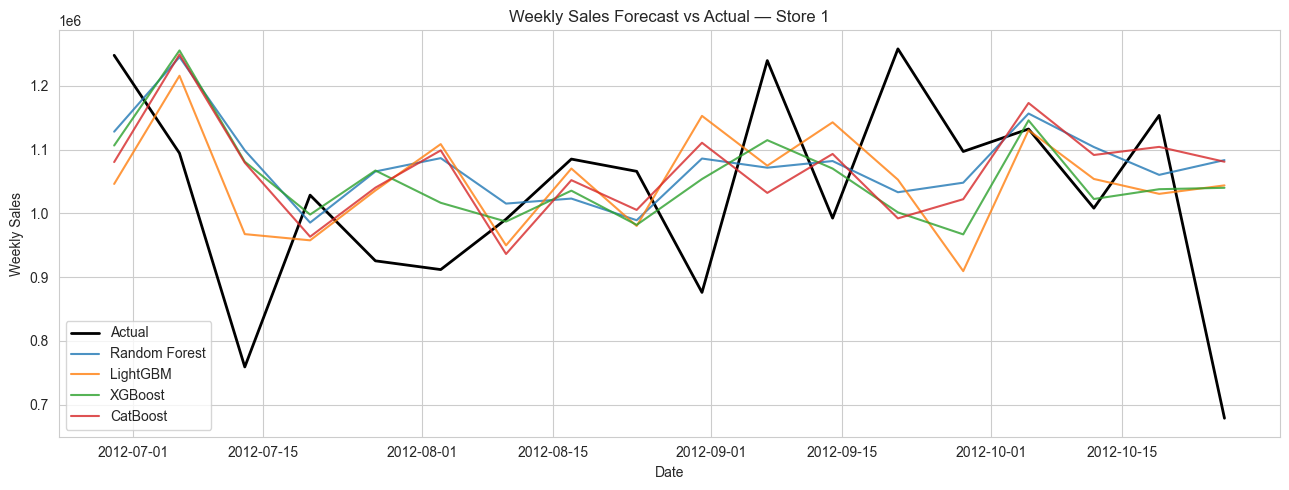

In [36]:
sample_store = 1
mask = test["Store"] == sample_store
plot_dates = test.loc[mask, "Date"]

plt.figure(figsize=(13, 5))
plt.plot(plot_dates, y_test[mask].values, label="Actual", color="black", linewidth=2)
for r in results:
    plt.plot(plot_dates, r["preds"][mask.values], label=r["Model"], alpha=0.8)
plt.title(f"Weekly Sales Forecast vs Actual — Store {sample_store}")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.legend()
plt.tight_layout()
plt.show()

In [37]:
lgb_model_low = lgb.LGBMRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=-1, num_leaves=31,
        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1, objective='quantile', alpha=0.1
    )
lgb_model_high = lgb.LGBMRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=-1, num_leaves=31,
        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1, objective='quantile', alpha=0.9
    )

lgb_model_low.fit(X_train, y_train)
lgb_model_high.fit(X_train, y_train)

y_low = lgb_model_low.predict(X_test)
y_high = lgb_model_high.predict(X_test)

coverage = ((y_test.values >= y_low) & (y_test.values <= y_high)).mean()
print(f"LightGBM P10–P90 coverage: {coverage:.2%} ({int(coverage * len(y_test))}/{len(y_test)})")


LightGBM P10–P90 coverage: 60.00% (486/810)


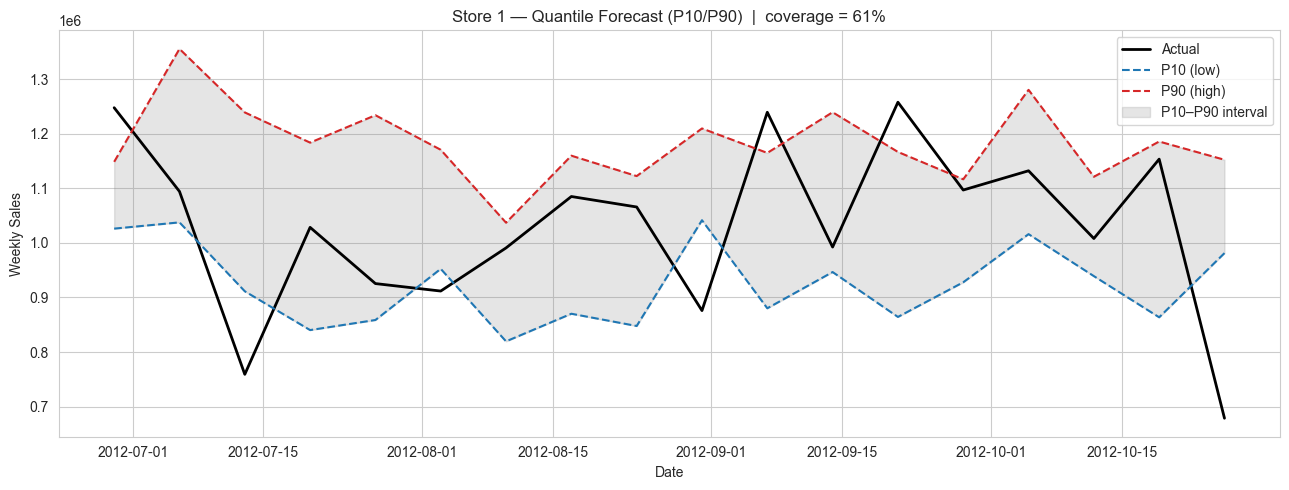

LightGBM P10–P90 coverage for Store 1: 61.11% (495/810)


In [38]:
sample_store = 1
mask = (test["Store"] == sample_store).values
plot_dates = test.loc[mask, "Date"]

plt.figure(figsize=(13, 5))
plt.plot(plot_dates, y_test[mask].values, label="Actual", color="black", linewidth=2)
plt.plot(plot_dates, y_low[mask], label="P10 (low)", color="tab:blue", linestyle="--")
plt.plot(plot_dates, y_high[mask], label="P90 (high)", color="tab:red", linestyle="--")
plt.fill_between(plot_dates, y_low[mask], y_high[mask], color="tab:gray", alpha=0.2, label="P10–P90 interval")

coverage = ((y_test[mask].values >= y_low[mask]) & (y_test[mask].values <= y_high[mask])).mean()
plt.title(f"Store {sample_store} — Quantile Forecast (P10/P90)  |  coverage = {coverage:.0%}")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.legend()
plt.tight_layout()
plt.show()
print(f"LightGBM P10–P90 coverage for Store {sample_store}: {coverage:.2%} ({int(coverage * len(y_test))}/{len(y_test)})")

In [39]:
cb_model_low = CatBoostRegressor(
    iterations=500, learning_rate=0.05, depth=6,
    random_state=RANDOM_STATE, verbose=0, loss_function='Quantile:alpha=0.1'
)

cb_model_high = CatBoostRegressor(
    iterations=500, learning_rate=0.05, depth=6,
    random_state=RANDOM_STATE, verbose=0, loss_function='Quantile:alpha=0.9'
)

cb_model_low.fit(X_train, y_train)
cb_model_high.fit(X_train, y_train)

y_low = cb_model_low.predict(X_test)
y_high = cb_model_high.predict(X_test)

coverage = ((y_test.values >= y_low) & (y_test.values <= y_high)).mean()
print(f"CatBoost P10-P90 coverage: {coverage:.2%} ({int(coverage * len(y_test))}/{len(y_test)})")

CatBoost P10-P90 coverage: 61.23% (496/810)


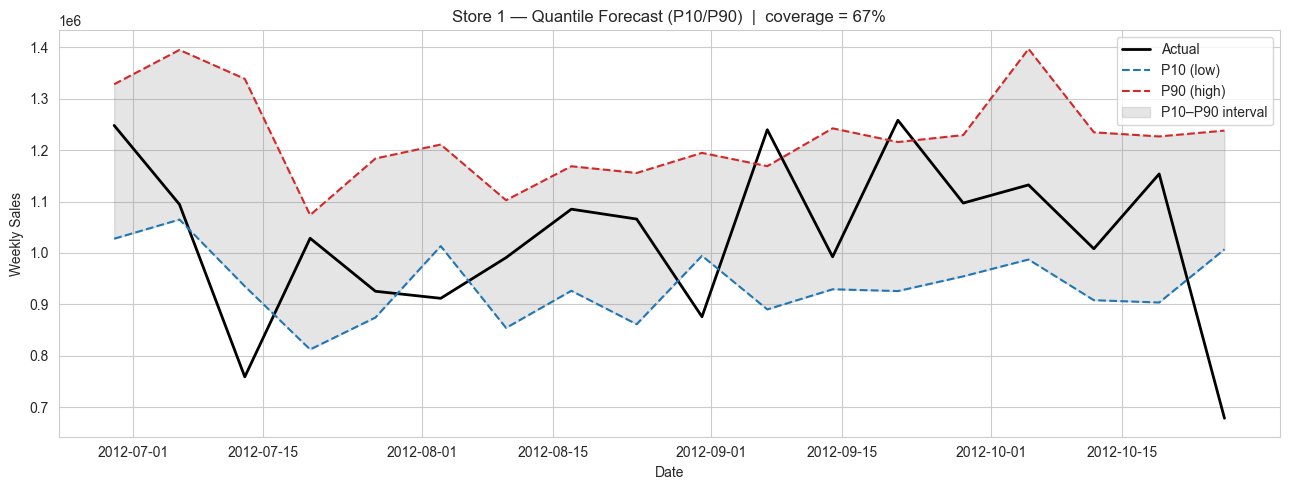

CatBoost P10–P90 coverage for Store 1: 66.67% (540/810)


In [40]:
sample_store = 1
mask = (test["Store"] == sample_store).values
plot_dates = test.loc[mask, "Date"]

plt.figure(figsize=(13, 5))
plt.plot(plot_dates, y_test[mask].values, label="Actual", color="black", linewidth=2)
plt.plot(plot_dates, y_low[mask], label="P10 (low)", color="tab:blue", linestyle="--")
plt.plot(plot_dates, y_high[mask], label="P90 (high)", color="tab:red", linestyle="--")
plt.fill_between(plot_dates, y_low[mask], y_high[mask], color="tab:gray", alpha=0.2, label="P10–P90 interval")

coverage = ((y_test[mask].values >= y_low[mask]) & (y_test[mask].values <= y_high[mask])).mean()
plt.title(f"Store {sample_store} — Quantile Forecast (P10/P90)  |  coverage = {coverage:.0%}")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.legend()
plt.tight_layout()
plt.show()
print(f"CatBoost P10–P90 coverage for Store {sample_store}: {coverage:.2%} ({int(coverage * len(y_test))}/{len(y_test)})")

In [41]:
cal_split_date = data["Date"].quantile(0.7)
test_split_date = data["Date"].quantile(0.85)

train = data[data["Date"] <= cal_split_date]
calib = data[(data["Date"] > cal_split_date) & (data["Date"] <= test_split_date)]
test  = data[data["Date"] > test_split_date]

X_train, y_train = train[selected], train[target_col]
X_calib, y_calib = calib[selected], calib[target_col]
X_test,  y_test  = test[selected],  test[target_col]

print(f"Train: {X_train.shape}  |  Calib: {X_calib.shape}  |  Test: {X_test.shape}")
print(f"Calib split date: {cal_split_date.date()}  |  Test split date: {test_split_date.date()}")

Train: (2880, 22)  |  Calib: (630, 22)  |  Test: (585, 22)
Calib split date: 2012-04-20  |  Test split date: 2012-07-27


In [42]:
# CatBoost Quantile + CQR 
alpha = 0.1  # target miscoverage → 90% intervals

cb_model_low = CatBoostRegressor(
        iterations=500, learning_rate=0.05, depth=6,
        random_state=RANDOM_STATE, verbose=0, loss_function=f'Quantile:alpha={alpha/2}')

cb_model_high = CatBoostRegressor(
        iterations=500, learning_rate=0.05, depth=6,
        random_state=RANDOM_STATE, verbose=0, loss_function=f'Quantile:alpha={1-alpha/2}')

cb_model_low.fit(X_train, y_train)
cb_model_high.fit(X_train, y_train)

# Predict on calibration set
q_low_cal = cb_model_low.predict(X_calib)
q_high_cal = cb_model_high.predict(X_calib)

# how much the true y falls outside [q_low, q_high]
scores = np.maximum(q_low_cal - y_calib, y_calib - q_high_cal)

# Finite-sample corrected quantile 
n = len(scores)
q = np.quantile(scores, np.ceil((n + 1) * (1 - alpha)) / n)

# Predict on test set
q_low_test = cb_model_low.predict(X_test)
q_high_test = cb_model_high.predict(X_test)

y_low  = q_low_test  - q
y_high = q_high_test + q

y_pred = 0.5 * (q_low_test + q_high_test)

coverage = ((y_test.values >= y_low) & (y_test.values <= y_high)).mean()

print(f"Coverage: {coverage:.3f} (target ~ {1-alpha})")

Coverage: 0.882 (target ~ 0.9)


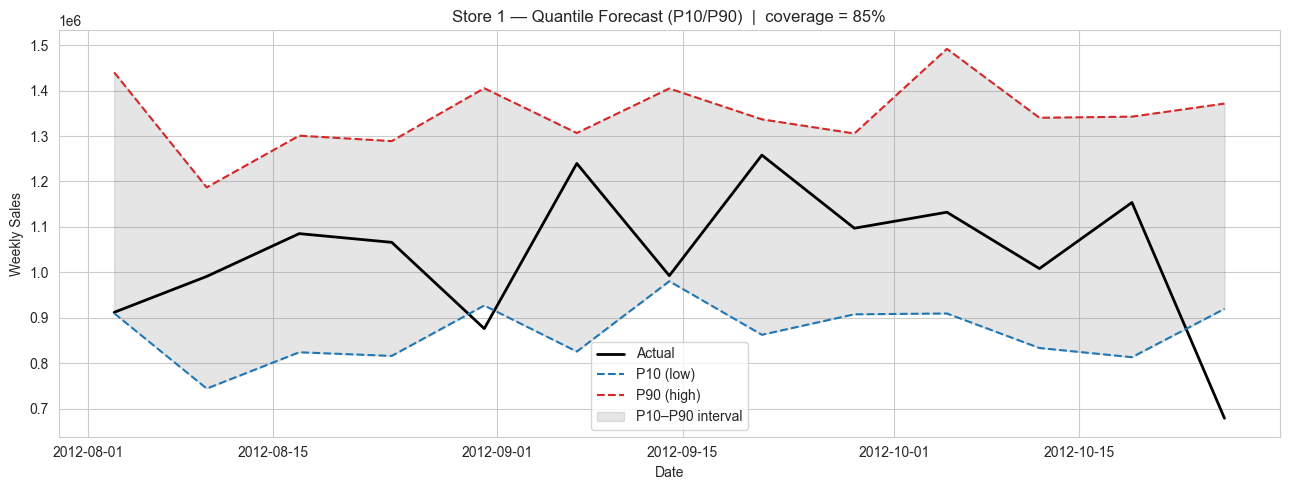

CatBoost P10–P90 coverage for Store 1: 84.62% (495/585)


In [45]:
sample_store = 1
mask = (test["Store"] == sample_store).values
plot_dates = test.loc[mask, "Date"]

plt.figure(figsize=(13, 5))
plt.plot(plot_dates, y_test[mask].values, label="Actual", color="black", linewidth=2)
plt.plot(plot_dates, y_low[mask], label="P10 (low)", color="tab:blue", linestyle="--")
plt.plot(plot_dates, y_high[mask], label="P90 (high)", color="tab:red", linestyle="--")
plt.fill_between(plot_dates, y_low[mask], y_high[mask], color="tab:gray", alpha=0.2, label="P10–P90 interval")

coverage = ((y_test[mask].values >= y_low[mask]) & (y_test[mask].values <= y_high[mask])).mean()
plt.title(f"Store {sample_store} — Quantile Forecast (P10/P90)  |  coverage = {coverage:.0%}")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.legend()
plt.tight_layout()
plt.show()
print(f"CatBoost P10–P90 coverage for Store {sample_store}: {coverage:.2%} ({int(coverage * len(y_test))}/{len(y_test)})")